torch.Size([1, 12, 288, 288]) torch.Size([1, 288, 288])
Model files: ['SmaAT_UNet_VQ_MSE-num32-commit0.75_rain_threshold_50_epoch=74-val_total_loss=0.183429.ckpt', 'SmaAT_UNet_VQ_CE_rain_threshold_50_epoch=34-val_total_loss=11646.433594.ckpt']
Persistence MSE: 2703.91162109375
SmaAT_UNet_VQ_MSE MSE: 980.154052734375
SmaAT_UNet_VQ_CE MSE: 1136.594482421875


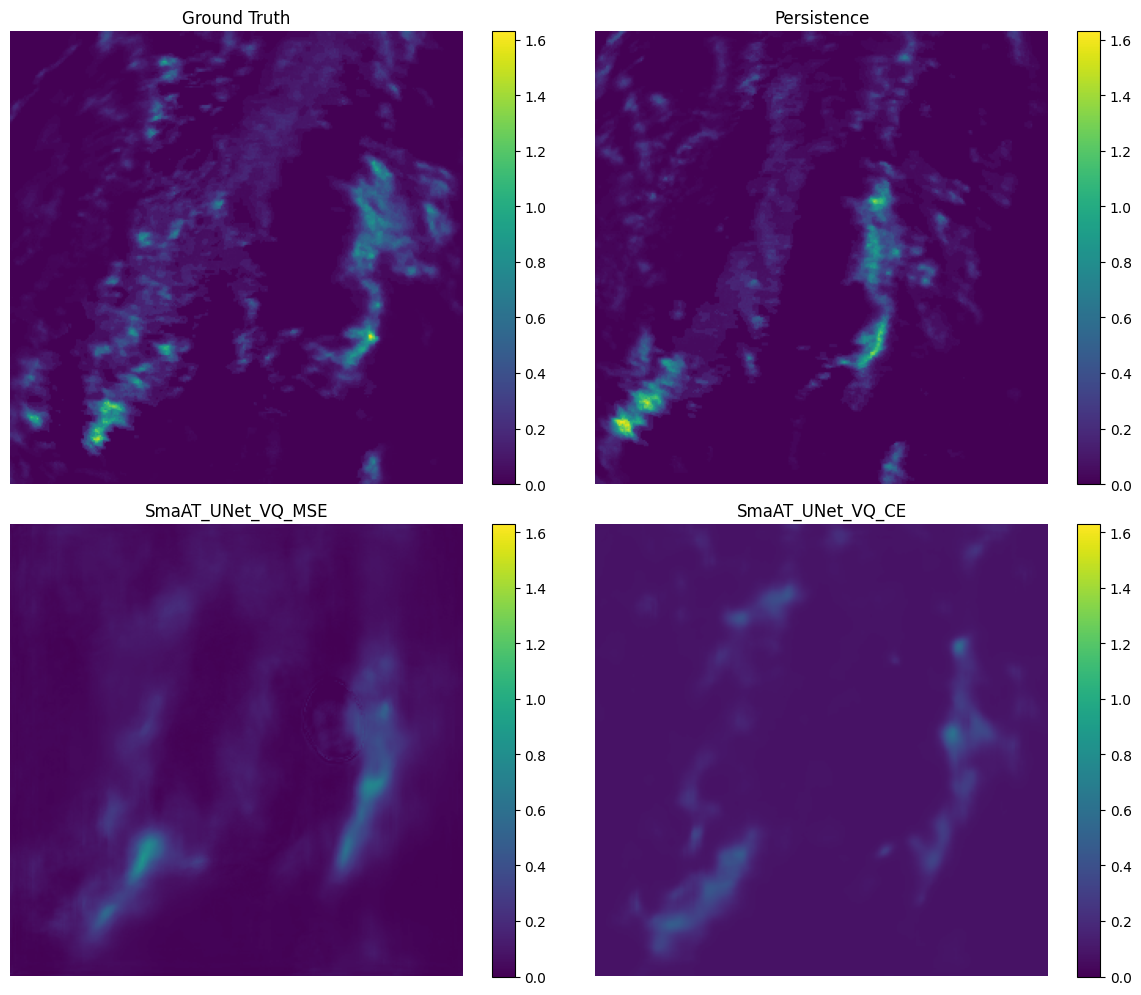

In [3]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import os
import models.unet_precip_regression_lightning as unet_regr
from models import SmaAT_UNet_VQ_lightning
from utils import dataset_precip
from utils.buckets import get_bucket_means

# Load dataset
dataset = dataset_precip.precipitation_maps_oversampled_h5(
    in_file="data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5",
    num_input_images=12,
    num_output_images=6, 
    train=False
)

# Pick a sample
x, y_true = dataset[1337]
x = torch.tensor(x).unsqueeze(0)
y_true = torch.tensor(y_true).unsqueeze(0)
print(x.shape, y_true.shape)

models_dir = "lightning/precip_regression/comparison"
precip_models = [m for m in os.listdir(models_dir) if ".ckpt" in m]
print("Model files:", precip_models)

# Persistence: last input frame prediction
loss_func = nn.MSELoss(reduction="sum")
print("Persistence MSE:", loss_func(x.squeeze()[-1]*47.83, y_true.squeeze()*47.83).item())

plot_images = dict()
for model_file in precip_models:
    if "SmaAT_UNet_VQ_MSE" in model_file:
        model_name = "SmaAT_UNet_VQ_MSE"
        model = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
    elif "SmaAT_UNet_VQ_CE" in model_file:
        model_name = "SmaAT_UNet_VQ_CE"
        model = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
    elif "SmaAT_UNet_VQ_MWAE" in model_file:
        model_name = "SmaAT_UNet_VQ_MWAE"
        model = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ
    elif "SmaAT_UNet" in model_file:
        model_name = "SmaAT_UNet"
        model = unet_regr.UNetDS_Attention
    elif "UNet" in model_file:
        model_name = "UNet"
        model = unet_regr.UNet
    else:
        raise NotImplementedError(f"Model not found: {model_file}")
    
    model = model.load_from_checkpoint(f"{models_dir}/{model_file}")
    model.to("cpu")
    model.eval()
    
    with torch.no_grad():
        y_pred = model(x)
        if isinstance(y_pred, tuple):
            y_pred = y_pred[0]
    # Remove batch dimension; now y_pred is either [channels, H, W] (for CE) or [1, H, W] (regression)
    y_pred = y_pred[0]
    
    # Adapt for CE loss: if more than one channel, compute continuous prediction.
    if y_pred.ndim == 3 and y_pred.shape[0] > 1:
        bucket_means = get_bucket_means(device=y_pred.device)
        p = torch.softmax(y_pred, dim=0)
        y_pred_cont = torch.sum(p * bucket_means.view(-1, 1, 1), dim=0)
    else:
        y_pred_cont = y_pred.squeeze(0) if y_pred.ndim == 3 else y_pred

    print(model_name, "MSE:", loss_func(y_pred_cont*47.83, y_true.squeeze()*47.83).item())
    plot_images[model_name] = y_pred_cont

# Select images for 2x2 grid:
# We'll show: Ground Truth, Persistence, and predictions from the first two models in plot_images.
model_keys = list(plot_images.keys())
selected = {}
if len(model_keys) >= 2:
    selected[model_keys[0]] = plot_images[model_keys[0]]
    selected[model_keys[1]] = plot_images[model_keys[1]]
elif len(model_keys) == 1:
    selected[model_keys[0]] = plot_images[model_keys[0]]

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot Ground Truth in top-left
im0 = axs[0, 0].imshow(y_true.squeeze()*47.83, cmap="viridis")
axs[0, 0].set_title("Ground Truth")
fig.colorbar(im0, ax=axs[0, 0])
axs[0, 0].axis("off")

# Plot Persistence in top-right
im1 = axs[0, 1].imshow(x.squeeze()[-1]*47.83, cmap="viridis",
                        vmax=torch.max(y_true*47.83), vmin=torch.min(y_true*47.83))
axs[0, 1].set_title("Persistence")
fig.colorbar(im1, ax=axs[0, 1])
axs[0, 1].axis("off")

# Plot first model prediction in bottom-left (if available)
if len(selected) >= 1:
    key = list(selected.keys())[0]
    im2 = axs[1, 0].imshow(selected[key]*47.83, cmap="viridis",
                            vmax=torch.max(y_true*47.83), vmin=torch.min(y_true*47.83))
    axs[1, 0].set_title(key)
    fig.colorbar(im2, ax=axs[1, 0])
    axs[1, 0].axis("off")
else:
    axs[1, 0].axis("off")

# Plot second model prediction in bottom-right (if available)
if len(selected) >= 2:
    key = list(selected.keys())[1]
    im3 = axs[1, 1].imshow(selected[key]*47.83, cmap="viridis",
                            vmax=torch.max(y_true*47.83), vmin=torch.min(y_true*47.83))
    axs[1, 1].set_title(key)
    fig.colorbar(im3, ax=axs[1, 1])
    axs[1, 1].axis("off")
else:
    axs[1, 1].axis("off")

plt.tight_layout()
plt.show()
